> **This is a research notebook — one of seven, one per section of the paper.**
>
> For the presentation version, read the two self-contained notebooks in
> [`final/`](../final/) instead: [`1_information_bottleneck.ipynb`](../final/1_information_bottleneck.ipynb) (the whole argument, end to end) and [`2_transformer_extension.ipynb`](../final/2_transformer_extension.ipynb).
>
> This one is the deep dive on the steelman: task-irrelevant information, and *when* it is discarded.

# 5 — When compression *does* happen, and when it happens

**Reproduces:** paper section 5 — figure 6.

---

## The steelman

Notebooks 2–4 dismantled three claims. But a nagging intuition survives all of them:

> If some input channels carry nothing but noise, then surely good generalisation
> *requires* throwing them away. Isn't that compression, and isn't it necessary?

The intuition is sound. The paper takes it seriously and constructs the cleanest possible
version of it: split the input into a **task-relevant** block and a **task-irrelevant**
block, with the teacher's weights on the irrelevant block set to exactly zero.

$$X = [\,X_{\mathrm{rel}}\;\; X_{\mathrm{irrel}}\,], \qquad
  Y = W_o^{\mathrm{rel}} X_{\mathrm{rel}} + \epsilon_o, \qquad
  W_o^{\mathrm{irrel}} = 0.$$

Here $X_{\mathrm{irrel}}$ is pure nuisance by construction. A network that generalises
**must** end up ignoring it.

## The question that actually matters

The IB story is not just "compression happens" — it is that compression happens in a
**separate second phase**, *after* fitting. So we ask two separate questions:

1. Does $I(X_{\mathrm{irrel}};T)$ decrease? *(the paper's answer: yes)*
2. Does it decrease **after** fitting finishes, or **at the same time**?
   *(the paper's answer: at the same time)*

Everything here is exact — a linear network, so equation (6) and the subspace formula below
give the true values with no estimator involved.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "ibdl").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from ibdl import plotting
plotting.use_paper_style()
FIGDIR = ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)

print("project root:", ROOT)

project root: /home/hooman/Desktop/InfoTheory/Project


## 5.1 Measuring information about a subspace

For $T = \bar{W}X + \epsilon_{MI}$, conditioning on one block leaves the *other* block
acting as extra noise. Writing $S$ for the block of interest and $\bar S$ for its
complement,

$$I(T; X_S) = \underbrace{\tfrac12\log\big|\bar{W}\Sigma_X\bar{W}^\top + \sigma_{MI}^2 I\big|}_{H(T)}
 - \underbrace{\tfrac12\log\big|\bar{W}_{\bar S}\Sigma_{\bar S}\bar{W}_{\bar S}^\top
   + \sigma_{MI}^2 I\big|}_{H(T \mid X_S)}.$$

This is a genuine mutual information, not a proxy, which is what makes the answer sharp.

Note the identity it implies. Since $X_{\mathrm{rel}} \perp X_{\mathrm{irrel}}$, the chain
rule gives

$$I(X;T) = I(X_{\mathrm{rel}};T) + I(X_{\mathrm{irrel}};T)
        + \underbrace{I(X_{\mathrm{rel}}; X_{\mathrm{irrel}} \mid T)}_{\ge\, 0},$$

so the parts are **sub-additive**: observing $T$ makes two a-priori-independent blocks
dependent ("explaining away"), and that synergy is the gap. It follows that
$I(X_{\mathrm{irrel}};T)$ can fall while $I(X;T)$ rises — which is exactly what happens.

In [2]:
from ibdl.cache import cached
from ibdl.experiments import RelevanceConfig, run_relevance

cfg = RelevanceConfig(seed=0)   # defaults: 30 relevant + 70 irrelevant, P=1000,
                                # SGD batch 5, teacher SNR 5, small init, 3000 epochs
res = cached(cfg.tag, lambda: run_relevance(cfg))
L = res.log
H = 0  # the hidden layer

print(f"input      : {cfg.n_relevant} task-relevant + {cfg.n_irrelevant} task-irrelevant dims")
print(f"training   : P = {cfg.n_train}, SGD with {cfg.batch_size} samples/batch, "
      f"{cfg.n_epochs} epochs, teacher SNR = {cfg.snr:g}")
print(f"test MSE   : {L.test_loss[0]:.3f} -> {L.test_loss[-1]:.3f}")
print(f"exact E_g  : {res.E_g[0]:.3f} -> {res.E_g[-1]:.3f}   "
      f"(irreducible floor = {1.0 / cfg.snr:.3f})")
print(f"I(T;Y)     : {res.I_TY[0, H]:.4f} -> {res.I_TY[-1, H]:.4f} bits  "
      f"(the network really does learn the task)")

[cache] loaded 'relevance_30rel_70irr_P1000_snr5_lr0.05_e3000_i0.03_s0' (6.2 MB)
input      : 30 task-relevant + 70 task-irrelevant dims
training   : P = 1000, SGD with 5 samples/batch, 3000 epochs, teacher SNR = 5
test MSE   : 0.396 -> 0.225
exact E_g  : 0.400 -> 0.226   (irreducible floor = 0.200)
I(T;Y)     : 0.0005 -> 0.1107 bits  (the network really does learn the task)


## 5.2 Figure 6 — the three panels

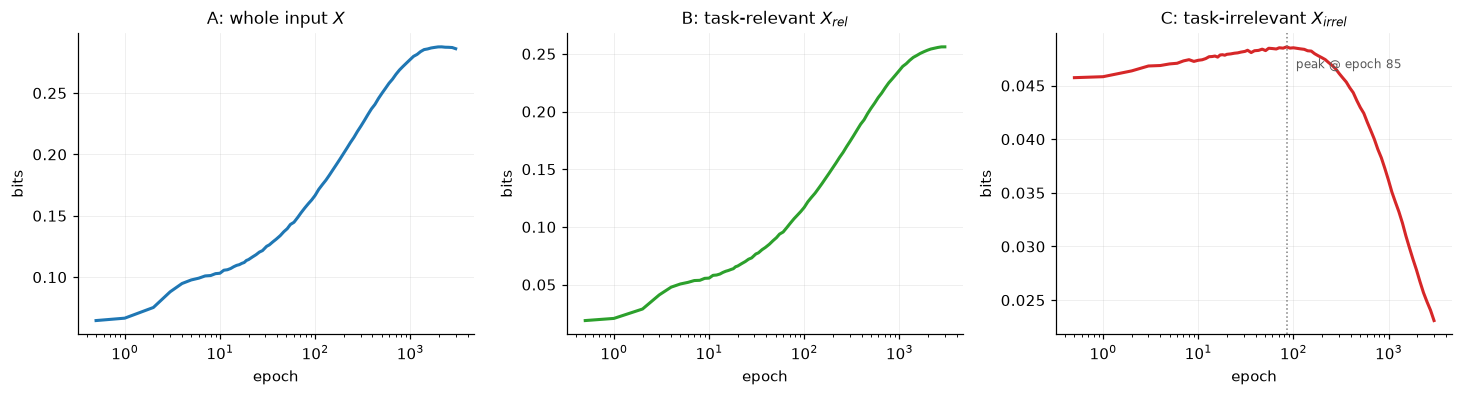

A: whole input $X$                  0.065 ->  0.286 bits   peak  0.288 @ epoch  2136   drop +0.002   no compression
B: task-relevant $X_{rel}$          0.019 ->  0.256 bits   peak  0.256 @ epoch  3000   drop +0.000   no compression
C: task-irrelevant $X_{irrel}$      0.046 ->  0.023 bits   peak  0.049 @ epoch    85   drop +0.026   COMPRESSES


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.7))
x = np.maximum(L.epochs, 0.5)

panels = [
    ("A: whole input $X$", res.I_XT[:, H], "#1f77b4"),
    ("B: task-relevant $X_{rel}$", res.I_XrelT[:, H], "#2ca02c"),
    ("C: task-irrelevant $X_{irrel}$", res.I_XirrT[:, H], "#d62728"),
]
for ax, (title, y, c) in zip(axes, panels):
    ax.plot(x, y, color=c, lw=2)
    ax.set_xscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel("bits")
    ax.set_title(title)
    pk = int(np.argmax(y))
    if y.max() - y[-1] > 0.01:
        ax.axvline(x[pk], ls=":", color="0.5", lw=1)
        ax.annotate(f"peak @ epoch {L.epochs[pk]}", xy=(x[pk], y[pk]),
                    xytext=(6, -14), textcoords="offset points", fontsize=8, color="0.35")
fig.tight_layout()
plotting.save(fig, "fig06_simultaneous", FIGDIR)
plt.show()

for title, y, _ in panels:
    verdict = "COMPRESSES" if y.max() - y[-1] > 0.01 else "no compression"
    print(f"{title:34s} {y[0]:6.3f} -> {y[-1]:6.3f} bits   "
          f"peak {y.max():6.3f} @ epoch {L.epochs[int(np.argmax(y))]:5d}   "
          f"drop {y.max() - y[-1]:+.3f}   {verdict}")

So the intuition is **half** right:

* **Panel A** — information about the input as a whole does *not* compress. Anyone watching
  only $I(X;T)$, as the original information-plane analysis does, would see no compression
  and conclude nothing was discarded.
* **Panel B** — information about the relevant subspace rises robustly. That is fitting.
* **Panel C** — information about the irrelevant subspace rises and then **falls**. Genuine
  compression of genuinely irrelevant information.

Panel C is a real effect, and it is invisible in panel A. That is a substantive finding in
its own right: an aggregate $I(X;T)$ curve can hide the compression that actually matters.

## 5.3 The timing question — is there a second phase?

This is the claim the paper is testing. Overlay fitting (panel B, and $I(T;Y)$) with
compression (panel C) on a common axis. If IB were right, the red curve should start
falling only *after* the green one has flattened.

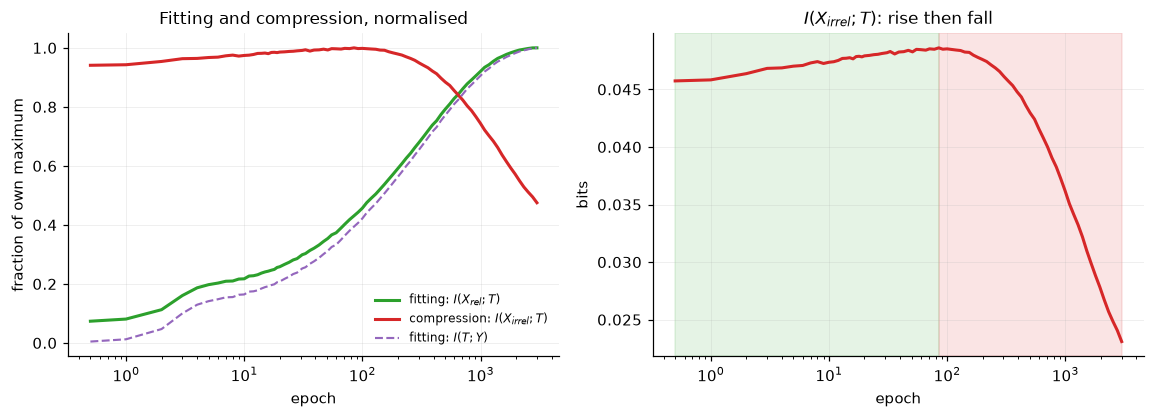

I(X_irrel;T) peaks (compression begins)      : epoch 85
I(X_rel;T) reaches 50% of its total rise     : epoch 154
I(X_rel;T) reaches 90% of its total rise     : epoch 995

When compression of the irrelevant subspace BEGINS, fitting of the relevant
subspace is only 39% complete.

=> Compression starts BEFORE fitting finishes. The two are INTERLEAVED,
   not sequential. There is no separate second phase.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.9))

ax = axes[0]
rel = res.I_XrelT[:, H]
irr = res.I_XirrT[:, H]
ax.plot(x, rel / rel.max(), color="#2ca02c", lw=2, label=r"fitting: $I(X_{rel};T)$")
ax.plot(x, irr / irr.max(), color="#d62728", lw=2, label=r"compression: $I(X_{irrel};T)$")
ax.plot(x, res.I_TY[:, H] / res.I_TY[:, H].max(), color="#9467bd", lw=1.4, ls="--",
        label=r"fitting: $I(T;Y)$")
ax.set_xscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("fraction of own maximum")
ax.set_title("Fitting and compression, normalised")
ax.legend(loc="lower right", fontsize=8)

# Where is each process at its half-way point?
def cross_frac(y, frac=0.5, rising=True):
    z = (y - y.min()) / max(np.ptp(y), 1e-12)
    idx = np.argmax(z >= frac) if rising else np.argmax(z <= frac)
    return L.epochs[idx]

ax = axes[1]
ax.plot(x, irr, color="#d62728", lw=2)
ax.axvspan(x[0], x[int(np.argmax(irr))], color="#2ca02c", alpha=0.12)
ax.axvspan(x[int(np.argmax(irr))], x[-1], color="#d62728", alpha=0.12)
ax.set_xscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("bits")
ax.set_title(r"$I(X_{irrel};T)$: rise then fall")
fig.tight_layout()
plotting.save(fig, "fig06_timing", FIGDIR)
plt.show()

peak_irr = L.epochs[int(np.argmax(irr))]
rel_50 = cross_frac(rel, 0.5, rising=True)
rel_90 = cross_frac(rel, 0.9, rising=True)
print(f"I(X_irrel;T) peaks (compression begins)      : epoch {peak_irr}")
print(f"I(X_rel;T) reaches 50% of its total rise     : epoch {rel_50}")
print(f"I(X_rel;T) reaches 90% of its total rise     : epoch {rel_90}")
print()
frac_done = (rel[np.argmax(irr)] - rel[0]) / (rel[-1] - rel[0])
print(f"When compression of the irrelevant subspace BEGINS, fitting of the relevant")
print(f"subspace is only {100 * frac_done:.0f}% complete.")
print()
if peak_irr < rel_90:
    print("=> Compression starts BEFORE fitting finishes. The two are INTERLEAVED,")
    print("   not sequential. There is no separate second phase.")
else:
    print("=> Compression starts after fitting completes (a separate phase).")

## 5.4 Why the aggregate curve hides it

The sub-additivity identity from section 5.1 explains the apparent paradox — how
$I(X_{\mathrm{irrel}};T)$ can fall while $I(X;T)$ rises. Let us verify it numerically and
watch the synergy term grow.

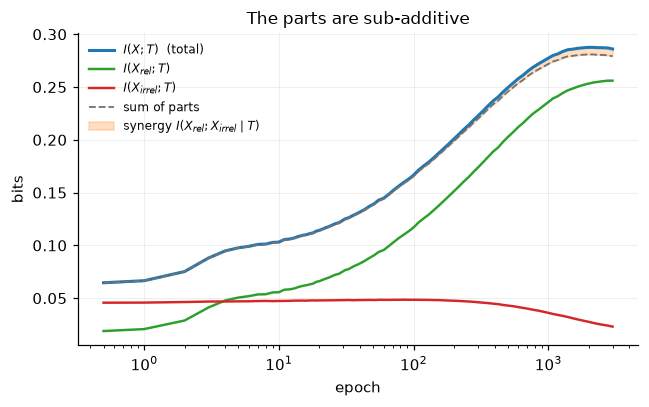

minimum synergy over training: +0.0000 bits  (must be >= 0; negative would mean a bug)
synergy at end               : +0.0069 bits

So I(X;T) can rise while I(X_irrel;T) falls, because the synergy term absorbs
the difference. Watching only I(X;T) tells you nothing about either part.


In [5]:
synergy = res.I_XT[:, H] - (res.I_XrelT[:, H] + res.I_XirrT[:, H])

fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.plot(x, res.I_XT[:, H], color="#1f77b4", lw=2, label=r"$I(X;T)$  (total)")
ax.plot(x, res.I_XrelT[:, H], color="#2ca02c", lw=1.6, label=r"$I(X_{rel};T)$")
ax.plot(x, res.I_XirrT[:, H], color="#d62728", lw=1.6, label=r"$I(X_{irrel};T)$")
ax.plot(x, res.I_XrelT[:, H] + res.I_XirrT[:, H], color="0.45", ls="--", lw=1.2,
        label="sum of parts")
ax.fill_between(x, res.I_XrelT[:, H] + res.I_XirrT[:, H], res.I_XT[:, H],
                color="#ff7f0e", alpha=0.25,
                label=r"synergy $I(X_{rel};X_{irrel}\mid T)$")
ax.set_xscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("bits")
ax.set_title("The parts are sub-additive")
ax.legend(fontsize=8)
fig.tight_layout()
plotting.save(fig, "fig06_synergy", FIGDIR)
plt.show()

print(f"minimum synergy over training: {synergy.min():+.4f} bits  "
      f"(must be >= 0; negative would mean a bug)")
print(f"synergy at end               : {synergy[-1]:+.4f} bits")
print()
print("So I(X;T) can rise while I(X_irrel;T) falls, because the synergy term absorbs")
print("the difference. Watching only I(X;T) tells you nothing about either part.")

## 5.5 Robustness across seeds

 seed  I(Xtot;T) drop  I(Xrel;T) rise  I(Xirr;T) drop   fitting % done
--------------------------------------------------------------------------
    0           0.002          +0.237           0.026              39%
    1           0.004          +0.224           0.027              33%
    2           0.003          +0.273           0.029               7%


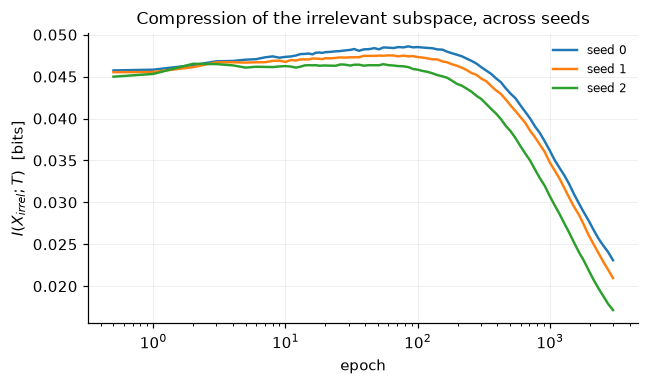

In [6]:
seeds = [0, 1, 2]
runs = []
for s in seeds:
    c = RelevanceConfig(seed=s)
    runs.append(cached(c.tag, lambda c=c: run_relevance(c), verbose=False))

print(f"{'seed':>5s} {'I(Xtot;T) drop':>15s} {'I(Xrel;T) rise':>15s} "
      f"{'I(Xirr;T) drop':>15s} {'fitting % done':>16s}")
print("-" * 74)
for s, r in zip(seeds, runs):
    rel_, irr_, tot_ = r.I_XrelT[:, H], r.I_XirrT[:, H], r.I_XT[:, H]
    pk = int(np.argmax(irr_))
    done = 100 * (rel_[pk] - rel_[0]) / max(rel_[-1] - rel_[0], 1e-12)
    print(f"{s:>5d} {tot_.max() - tot_[-1]:>15.3f} {rel_[-1] - rel_[0]:>+15.3f} "
          f"{irr_.max() - irr_[-1]:>15.3f} {done:>15.0f}%")

fig, ax = plt.subplots(figsize=(6.0, 3.6))
for s, r in zip(seeds, runs):
    xx = np.maximum(r.log.epochs, 0.5)
    ax.plot(xx, r.I_XirrT[:, H], label=f"seed {s}", lw=1.6)
ax.set_xscale("log"); ax.set_xlabel("epoch")
ax.set_ylabel(r"$I(X_{irrel};T)$  [bits]")
ax.set_title("Compression of the irrelevant subspace, across seeds")
ax.legend()
fig.tight_layout()
plotting.save(fig, "fig06_seeds", FIGDIR)
plt.show()

## Takeaways

1. When part of the input is genuinely task-irrelevant, the network **does** compress its
   information about that part. The intuition behind the IB story is not empty.
2. But that compression is **simultaneous with fitting**, not a subsequent phase. By the
   time $I(X_{\mathrm{irrel}};T)$ starts falling, the relevant subspace is still being
   learned.
3. The compression is **invisible in $I(X;T)$**, which keeps rising throughout — the
   sub-additivity gap $I(X_{\mathrm{rel}};X_{\mathrm{irrel}}\mid T) \ge 0$ absorbs it.
   The standard information plane therefore measures the wrong thing for this purpose.
4. Taken together with notebooks 2–4: the two-phase picture is an artefact of a
   double-saturating nonlinearity plus binning; the real compression that a task demands is
   interleaved with fitting and needs a subspace-resolved measure to see at all.

Next: [`06_mnist_kde.ipynb`](06_mnist_kde.ipynb) scales the analysis to MNIST.